In [1]:
import numpy as np
import torch
import sinv.torch_sparse_involution as tsi

import utility

torch.set_default_device('cuda')

dtype = torch.float32 
# dtype = torch.float64
torch.set_default_dtype(dtype)

def sol2image(BWHC, index=0):
    return BWHC[index].transpose(0,1).detach().cpu().numpy()

## Example: anisotropic Laplace equation

### prepare the input

In [2]:
ab_wh=((128,128), (5,5))

image_hwc = utility.simple_image()

problem, alpha, beta, bc, A_scipy, B_scipy, info = \
      utility.simple_matting_laplacian(ab_wh, image_hwc)

### method 1: tsi.schwarz_schur_involution

In [3]:
sol = tsi.schwarz_schur_involution(alpha, beta, boundary_condition=bc, wh=ab_wh[1], transposed_solve=False)

### method 2: tsi.sinv2d

In [4]:
x_BWHC = tsi.sinv2d(alpha, beta, 'Neumann', ab_wh)   # [1, 513, 513, C]

### method 3 (the fastest): sinv2d_via_jax

In [5]:
from sinv_torch_via_jax import sinv2d_via_jax, precompile_solver

# Jax versoin first compiles the solver. 
precompile_solver(ab_wh, batch_size=1, num_rhs=3, dtype=dtype)

In [6]:
import time
from sinv_torch_via_jax import sinv2d_via_jax

torch.cuda.synchronize()
t0 = time.time()

N = 100
for i in range(N): 
    x_BWHC = sinv2d_via_jax((i+1)*alpha, (i+1)*beta, ab_wh)
torch.cuda.synchronize()

print(f"solver time: {(time.time() - t0) * 1e3 / N:.1f} ms for A.shape={A_scipy.shape}, b.shape={B_scipy.shape}")

solver time: 10.2 ms for A.shape=(263169, 263169), b.shape=(263169, 3)


### visualize the output: the deconved image. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0015250836..0.99209195].


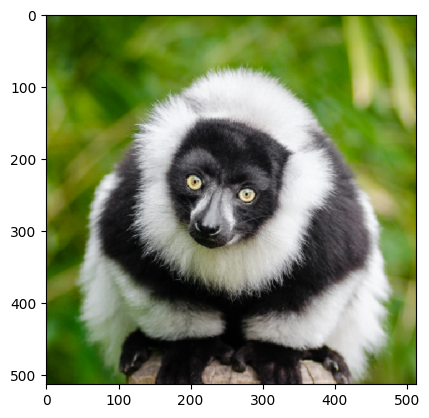

In [7]:
import matplotlib.pyplot as plt
plt.imshow(sol2image(x_BWHC))
plt.show()

### visualize the right-hand side. 

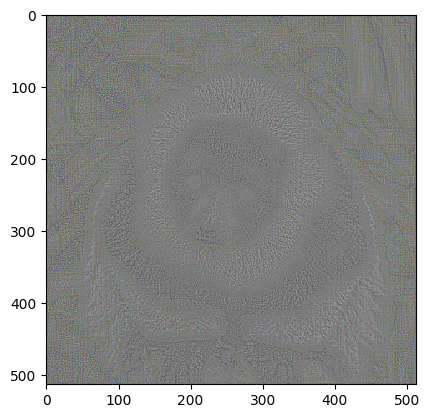

In [8]:
import matplotlib.pyplot as plt

rhs = B_scipy.reshape([513,513,3])
rhs = (rhs - rhs.min()) / (rhs.max() - rhs.min()) # otherwise rhs is not an image

plt.imshow(rhs)
plt.show()

## Example: Helmholtz equation

/home/wangyu/anaconda3/lib/python3.12/site-packages/torch/utils/_device.py:122: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return func(*args, **kwargs)


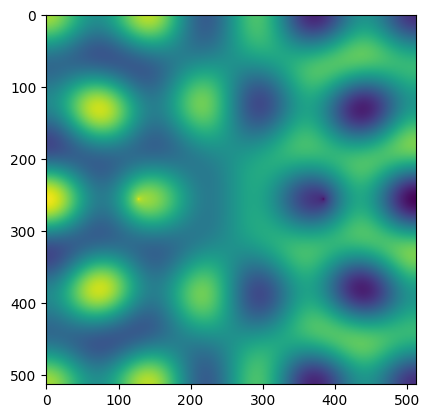

In [9]:
ab_wh=((128,128), (5,5))

problem, alpha, beta, bc, A_scipy, B_scipy, info = \
      utility.simple_helmholtz_equation(ab_wh)

x_BWHC = sinv2d_via_jax(alpha, beta, ab_wh)

import matplotlib.pyplot as plt
plt.imshow(sol2image(x_BWHC))
plt.show()